In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [119]:
df=pd.read_csv('/Users/lambardaar/Downloads/ml/gradient_boost/adult.csv')
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [120]:
df["workclass"]=df["workclass"].replace("?",df["workclass"].mode()[0])
df["occupation"]=df["occupation"].replace("?",df["occupation"].mode()[0])
df["native.country"]=df["native.country"].replace("?",df["native.country"].mode()[0])

In [121]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in df.columns:
    if df[i].dtype== 'object':
        df[i]=le.fit_transform(df[i])

df.head()


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,3,77053,11,9,6,9,1,4,0,0,4356,40,38,0
1,82,3,132870,11,9,6,3,1,4,0,0,4356,18,38,0
2,66,3,186061,15,10,6,9,4,2,0,0,4356,40,38,0
3,54,3,140359,5,4,0,6,4,4,0,0,3900,40,38,0
4,41,3,264663,15,10,5,9,3,4,0,0,3900,40,38,0


In [122]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,3,77053,11,9,6,9,1,4,0,0,4356,40,38,0
1,82,3,132870,11,9,6,3,1,4,0,0,4356,18,38,0
2,66,3,186061,15,10,6,9,4,2,0,0,4356,40,38,0
3,54,3,140359,5,4,0,6,4,4,0,0,3900,40,38,0
4,41,3,264663,15,10,5,9,3,4,0,0,3900,40,38,0


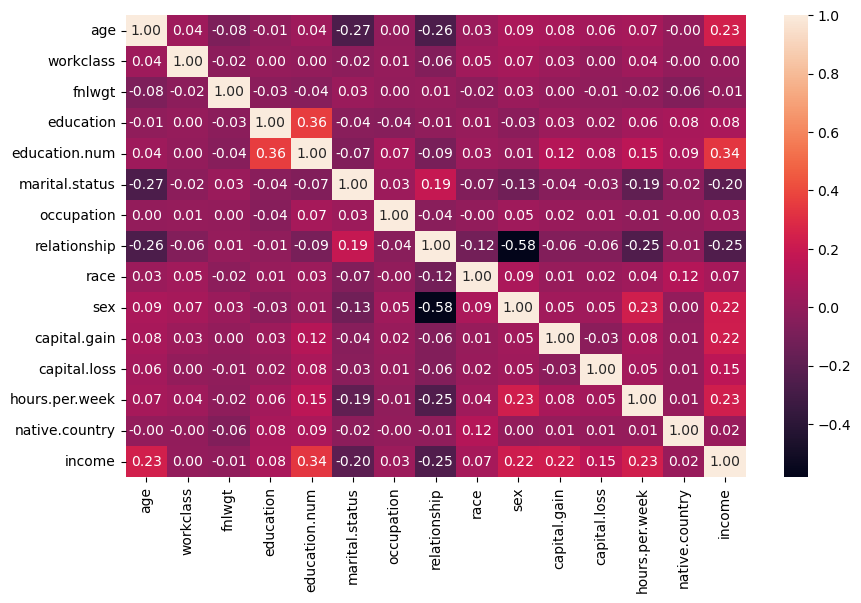

In [123]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,fmt=".2f")
plt.show()

In [124]:
t_columns=[]
for i in df.columns:
    cc=df[i].corr(df['income'])>0.2
    if cc>0.2 or cc<-0.2:
        t_columns.append(i)

print(t_columns)

['age', 'education.num', 'sex', 'capital.gain', 'hours.per.week', 'income']


In [125]:
x=df[['age', 'education.num', 'sex', 'capital.gain', 'hours.per.week']]
y=df['income']

In [126]:
x.head()
y.head()

0    0
1    0
2    0
3    0
4    0
Name: income, dtype: int64

In [127]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [128]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

gb.fit(X_train,y_train)
pred=gb.predict(X_test)

print("accuracy_score \n",accuracy_score(y_test,pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

accuracy_score 
 0.8400122831260556
Confusion Matrix:
 [[4751  225]
 [ 817  720]]
